In [4]:
# from pathlib import Path
# import sys

# import cv2
# import numpy as np
# import torch
# import pytorch_lightning as pl
# import matplotlib.pyplot as plt

# # Adjust this if your notebook is not in the repo root
# REPO_ROOT = Path(".").resolve()  # or Path("..").resolve() etc.
# sys.path.append(str(REPO_ROOT))

# from src.config.default import get_cfg_defaults
# from src.lightning.lightning_loftr import PL_LoFTR

import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from MatchAnything.imcui.ui.utils import get_matcher_zoo, load_config, DEVICE
from MatchAnything.imcui.api import ImageMatchingAPI


## Trying ELOFTR

In [2]:
def load_gray(path, resize=None):
    """
    Load image as grayscale float32 in [0,1].
    Works for RGB and 16-bit thermal (Boson).
    """
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Could not read image at {path}")

    # If 3-channel, convert to gray
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = img.astype(np.float32)

    max_val = img.max()
    if max_val > 1.0:
        # Heuristic: 16-bit vs 8-bit
        if max_val > 255:
            img /= 65535.0
        else:
            img /= 255.0

    if resize is not None:
        img = cv2.resize(img, (resize, resize), interpolation=cv2.INTER_AREA)

    return img  # H x W, float32 in [0,1]


def build_matcher(cfg_path, ckpt_path, imgresize=None, thr=None):
    """
    Build PL_LoFTR in test mode, on CPU, METHOD=matchanything_eloftr.
    """
    config = get_cfg_defaults()
    config.merge_from_file(str(cfg_path))

    pl.seed_everything(config.TRAINER.SEED)

    # Use MatchAnything ELoFTR branch
    config.METHOD = "matchanything_eloftr"

    # Optional: ROPE/NPE resize if used in config
    if hasattr(config.LOFTR.COARSE, "ROPE") and config.LOFTR.COARSE.ROPE:
        assert config.DATASET.NPE_NAME is not None
    if getattr(config.DATASET, "NPE_NAME", None) is not None and imgresize is not None:
        config.LOFTR.COARSE.NPE = [832, 832, imgresize, imgresize]

    # Disable FP16 (CPU-only)
    config.LOFTR.FP16 = False

    # Coarse matching threshold override if provided
    if thr is not None:
        config.LOFTR.MATCH_COARSE.THR = thr

    pl_loftr = PL_LoFTR(config, pretrained_ckpt=str(ckpt_path), test_mode=True)
    matcher = pl_loftr.matcher
    matcher.eval()  # stay on CPU

    return matcher, config


def match_two_images(img0_path, img1_path, cfg_path, ckpt_path,
                     resize=None, thr=None, use_fp16=False):
    """
    Match a single image pair using MatchAnything ELoFTR (CPU).
    `use_fp16` is ignored (kept for API compatibility).
    """
    matcher, config = build_matcher(
        cfg_path=cfg_path,
        ckpt_path=ckpt_path,
        imgresize=resize,
        thr=thr,
    )

    # Load images
    img0 = load_gray(img0_path, resize=resize)
    img1 = load_gray(img1_path, resize=resize)

    # Build batch for LoFTR: [B, 1, H, W] on CPU
    img0_t = torch.from_numpy(img0)[None, None].float()
    img1_t = torch.from_numpy(img1)[None, None].float()

    batch = {
        "image0": img0_t,
        "image1": img1_t,
    }

    # Forward (CPU, no autocast)
    with torch.no_grad():
        matcher(batch)

    mkpts0 = batch["mkpts0_f"].cpu().numpy()  # (N, 2)
    mkpts1 = batch["mkpts1_f"].cpu().numpy()  # (N, 2)
    mconf = batch["mconf"].cpu().numpy()      # (N,)

    return mkpts0, mkpts1, mconf, img0, img1


def visualize_matches(img0, img1, mkpts0, mkpts1):
    """
    Create a side-by-side visualization of matches and display inline.
    img0, img1: grayscale float32 [0,1]
    mkpts0, mkpts1: N x 2 in (x, y) pixel coordinates
    """
    # Convert grayscale float32 [0,1] to uint8 BGR
    im0 = (img0 * 255.0).clip(0, 255).astype(np.uint8)
    im1 = (img1 * 255.0).clip(0, 255).astype(np.uint8)

    im0 = cv2.cvtColor(im0, cv2.COLOR_GRAY2BGR)
    im1 = cv2.cvtColor(im1, cv2.COLOR_GRAY2BGR)

    h0, w0 = im0.shape[:2]
    h1, w1 = im1.shape[:2]
    h = max(h0, h1)
    w = w0 + w1

    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    canvas[:h0, :w0] = im0
    canvas[:h1, w0:w0 + w1] = im1

    # Draw matches
    for p0, p1 in zip(mkpts0, mkpts1):
        x0, y0 = p0
        x1, y1 = p1
        color = (0, 255, 0)
        cv2.circle(canvas, (int(x0), int(y0)), 2, color, -1)
        cv2.circle(canvas, (int(x1 + w0), int(y1)), 2, color, -1)
        cv2.line(canvas, (int(x0), int(y0)), (int(x1 + w0), int(y1)), color, 1)

    # Display inline in the notebook
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return canvas  # optional, if you want to reuse it



In [3]:

def show_epipolar_lines(img0, img1, pts0, pts1, F, sample_step=5):
    """
    img0, img1: grayscale uint8 or float images (same coordinate system as pts0, pts1).
    pts0, pts1: Nx2 inlier points (float).
    F: 3x3 fundamental matrix mapping img0 -> img1.
    sample_step: draw every Nth match for clarity.
    """
    # ensure uint8 images for drawing
    def to_uint8(im):
        if im.dtype != np.uint8:
            im = (im * 255.0).clip(0, 255).astype(np.uint8)
        return im

    img0_u8 = to_uint8(img0)
    img1_u8 = to_uint8(img1)

    # OpenCV expects (N,1,2)
    pts0_reshaped = pts0.reshape(-1, 1, 2).astype(np.float32)
    pts1_reshaped = pts1.reshape(-1, 1, 2).astype(np.float32)

    # Lines in image 1 corresponding to pts0 in image 0
    lines1 = cv2.computeCorrespondEpilines(pts0_reshaped, 1, F)  # from img0 to img1
    lines1 = lines1.reshape(-1, 3)

    # Lines in image 0 corresponding to pts1 in image 1
    lines0 = cv2.computeCorrespondEpilines(pts1_reshaped, 2, F)  # from img1 to img0
    lines0 = lines0.reshape(-1, 3)

    img0_with_lines = _draw_lines(img0_u8, lines0, pts0, sample_step=sample_step)
    img1_with_lines = _draw_lines(img1_u8, lines1, pts1, sample_step=sample_step)

    # Show side-by-side inline
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.title("Epipolar lines in RGB image")
    plt.imshow(cv2.cvtColor(img0_with_lines, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Epipolar lines in IR image")
    plt.imshow(cv2.cvtColor(img1_with_lines, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()

    return img0_with_lines, img1_with_lines


def _draw_lines(img, lines, pts, sample_step=1):
    """
    Draw epipolar lines and corresponding points on a single image.
    img: HxW or HxWx3 uint8
    lines: Nx3 (a,b,c) epipolar lines
    pts: Nx2 points
    sample_step: draw every Nth line for clarity
    """
    if img.ndim == 2:
        color_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        color_img = img.copy()

    h, w = color_img.shape[:2]

    for i in range(0, len(lines), sample_step):
        a, b, c = lines[i]
        # avoid division by zero
        if abs(b) < 1e-6:
            continue

        # line endpoints at x=0 and x=w
        x0, y0 = 0, int(-c / b)
        x1, y1 = w, int(-(c + a * w) / b)

        color = tuple(np.random.randint(0, 255, 3).tolist())
        cv2.line(color_img, (x0, y0), (x1, y1), color, 1)

        x, y = pts[i].astype(int)
        cv2.circle(color_img, (x, y), 3, color, -1)

    return color_img

In [4]:
cfg_path  = REPO_ROOT / "configs/models/eloftr_model.py"
ckpt_path = REPO_ROOT / "weights/matchanything_eloftr.ckpt"
img_rgb_path = REPO_ROOT / "imgs/rgb0.png"
img_ir_path = REPO_ROOT / "imgs/ir0.png"

resize = 640  # or None to keep original size

mkpts_rgb, mkpts_ir, mconf, img_rgb, img_ir = match_two_images(
    img0_path=img_rgb_path,
    img1_path=img_ir_path,
    cfg_path=cfg_path,
    ckpt_path=ckpt_path,
    resize=resize,
)

# print(f"#matches: {mkpts_rgb.shape[0]}")
# print("First 10 matches (x0, y0) -> (x1, y1), conf:")
# for i in range(min(10, mkpts_rgb.shape[0])):
#     print(mkpts_rgb[i], "->", mkpts_ir[i], "conf =", mconf[i])

visualize_matches(img_rgb, img_ir, mkpts_rgb, mkpts_ir)


NameError: name 'REPO_ROOT' is not defined

## ROMA (works)

In [5]:

CONFIG_PATH = "MatchAnything/config/config.yaml"


def limit_inliers(pred, max_inliers=800):
    """
    Limit number of inlier matches AFTER RANSAC.
    Works with MatchAnything / ROMA output dictionary.

    pred keys contain:
        'mkeypoints0_orig'  (raw)
        'mmkeypoints0_orig' (inliers after RANSAC)
    """
    if "mmkeypoints0_orig" not in pred:
        print("[WARN] No inlier matches (mmkeypoints*_orig) found in prediction.")
        return pred

    mk0 = pred["mmkeypoints0_orig"]
    mk1 = pred["mmkeypoints1_orig"]
    mconf = pred["mmconf"]

    if len(mk0) > max_inliers:
        print(f"[INFO] Limiting inliers: {len(mk0)} → {max_inliers}")
        pred["mmkeypoints0_orig"] = mk0[:max_inliers]
        pred["mmkeypoints1_orig"] = mk1[:max_inliers]
        pred["mmconf"] = mconf[:max_inliers]
    else:
        print(f"[INFO] Inliers OK: {len(mk0)} (limit={max_inliers})")

    return pred


def build_roma_matcher(config_path=CONFIG_PATH):
    """
    Build ROMA matcher via ImageMatchingAPI.
    """
    config = load_config(config_path)
    matcher_zoo = get_matcher_zoo(config["matcher_zoo"])

    if "matchanything_roma" not in matcher_zoo:
        raise RuntimeError("ROMA is not enabled in config/config.yaml")

    api = ImageMatchingAPI(conf=matcher_zoo["matchanything_roma"], device=DEVICE)
    return api

def match_two_images_roma(api, img_rgb_path, img_ir_path, max_inliers=800):
    """
    Match a single RGB–IR pair using MatchAnything ROMA.

    Returns:
        mkpts_rgb, mkpts_ir, mconf, img_rgb_gray, img_ir_gray
    where:
        mkpts_*: (N, 2) float32, (x, y) in original image coordinates
        mconf:   (N,) confidences
        img_*_gray: HxW float32 in [0,1] (for your visualization / epipolar code)
    """
    # Load RGB & IR (as color for ROMA)
    img_rgb = cv2.imread(str(img_rgb_path))  # BGR
    img_ir = cv2.imread(str(img_ir_path))    # BGR or grayscale, but we treat as color

    if img_rgb is None:
        raise FileNotFoundError(f"Could not read RGB image at {img_rgb_path}")
    if img_ir is None:
        raise FileNotFoundError(f"Could not read IR image at {img_ir_path}")

    # Convert BGR->RGB because MatchAnything expects RGB
    img_rgb_rgb = img_rgb[:, :, ::1][:, :, ::-1]
    img_ir_rgb = img_ir[:, :, ::1][:, :, ::-1]

    # Run ROMA
    pred = api(img_rgb_rgb, img_ir_rgb)

    # Use inliers if available
    if "mmkeypoints0_orig" in pred:
        print("Using inlier keypoints (mmkeypoints*_orig).")
        pred = limit_inliers(pred, max_inliers=max_inliers)
        mkpts_rgb = pred["mmkeypoints0_orig"]
        mkpts_ir = pred["mmkeypoints1_orig"]
        mconf = pred["mmconf"]
    else:
        print("Using raw keypoints (keypoints0/1).")
        mkpts_rgb = pred["keypoints0"]
        mkpts_ir = pred["keypoints1"]
        mconf = pred["confidence"] if "confidence" in pred else None

    # Convert to numpy arrays
    mkpts_rgb = np.asarray(mkpts_rgb, dtype=np.float32)
    mkpts_ir = np.asarray(mkpts_ir, dtype=np.float32)
    if mconf is not None:
        mconf = np.asarray(mconf, dtype=np.float32)
    else:
        mconf = np.ones(len(mkpts_rgb), dtype=np.float32)

    # Make grayscale float32 [0,1] copies for the rest of your pipeline
    rgb_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    # If IR is single-channel already, don’t convert
    if img_ir.ndim == 2:
        ir_gray = img_ir.astype(np.float32) / 255.0
    else:
        ir_gray = cv2.cvtColor(img_ir, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    return mkpts_rgb, mkpts_ir, mconf, rgb_gray, ir_gray

def visualize_matches(img0, img1, mkpts0, mkpts1):
    im0 = (img0 * 255.0).clip(0, 255).astype(np.uint8)
    im1 = (img1 * 255.0).clip(0, 255).astype(np.uint8)

    im0 = cv2.cvtColor(im0, cv2.COLOR_GRAY2BGR)
    im1 = cv2.cvtColor(im1, cv2.COLOR_GRAY2BGR)

    h0, w0 = im0.shape[:2]
    h1, w1 = im1.shape[:2]
    h = max(h0, h1)
    w = w0 + w1

    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    canvas[:h0, :w0] = im0
    canvas[:h1, w0:w0 + w1] = im1

    for p0, p1 in zip(mkpts0, mkpts1):
        x0, y0 = p0
        x1, y1 = p1
        color = (0, 255, 0)
        cv2.circle(canvas, (int(x0), int(y0)), 2, color, -1)
        cv2.circle(canvas, (int(x1 + w0), int(y1)), 2, color, -1)
        cv2.line(canvas, (int(x0), int(y0)), (int(x1 + w0), int(y1)), color, 1)

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return canvas


In [ ]:
import numpy as np

# --- RGB Intrinsics ---
K_rgb0 = np.array([
    [889.44722255,   0.0,         365.30215844],
    [  0.0,         890.67612482, 285.76081066],
    [  0.0,           0.0,         1.0        ]
], dtype=np.float64)

K_rgb1 = np.array([
    [889.81741800,   0.0,         375.16051052],
    [  0.0,         891.25501167, 277.33320298],
    [  0.0,           0.0,         1.0        ]
], dtype=np.float64)

# --- IR Intrinsics ---

K_ir0 = np.array([
    [637.75776234,   0.0,         328.34835582],
    [  0.0,         638.33548688, 253.27167231],
    [  0.0,           0.0,         1.0        ]
], dtype=np.float64)

K_ir1 = np.array([
    [626.20337312,   0.0,         314.71543108],
    [  0.0,         625.49045673, 256.79714611],
    [  0.0,           0.0,         1.0        ]
], dtype=np.float64)

# --- Distortion Coefficients ---
d_rgb0 = np.array([-0.20743818, 0.14175898, 0.00112518, -0.00010317], dtype=np.float64)
d_rgb1 = np.array([-0.20879479, 0.14454576, -0.00018156, 0.00030712], dtype=np.float64)

d_ir0 = np.array([-0.20450165, 0.14743368, 1.3691e-05, -0.00029961, 0.0], dtype=np.float64)
d_ir1 = np.array([-0.19543806, 0.12250751, -0.00088481, -0.00210175, 0.0], dtype=np.float64)

# --- Extrinsics ---
q_1_0 = np.array([ 0.01308697, -0.0132229, -0.00458315, 0.99981642], dtype=np.float64)
t_1_0 = np.array([ 0.32019253,  0.00262298, -0.00700941], dtype=np.float64)

*****************cuda, False**************************


/home/nail/miniconda3/envs/gtsam-env/lib/python3.10/site-packages/pytorch_lightning/profiler/__init__.py:36: LightningDeprecationWarning: `pytorch_lightning.profiler.PassThroughProfiler` is deprecated in v1.9.0 and will be removed in v2.0.0. Use the equivalent `pytorch_lightning.profilers.PassThroughProfiler` class instead.
  rank_zero_deprecation(
2025-12-04 04:18:40.769 | INFO     | MatchAnything.src.lightning.lightning_loftr:__init__:76 - Load model from:<All keys matched successfully>
[2025/12/04 04:18:40 hloc INFO] Loading matchanything_roma model done
[2025/12/04 04:18:43 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/04 04:18:43 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


Using inlier keypoints (mmkeypoints*_orig).
[INFO] Limiting inliers: 965 → 800
#matches (after inlier limiting): 800


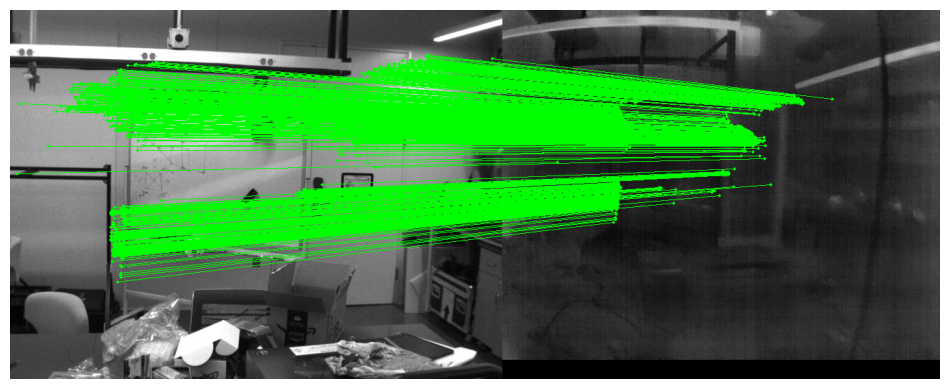

NameError: name 'show_epipolar_lines' is not defined

In [7]:
img_rgb_path = "imgs/rgb0.png"
img_ir_path  = "imgs/ir0.png"

# 1) Build ROMA matcher
api = build_roma_matcher(CONFIG_PATH)

# 2) Get matches via ROMA
mkpts_rgb, mkpts_ir, mconf, img_rgb, img_ir = match_two_images_roma(
    api,
    img_rgb_path=img_rgb_path,
    img_ir_path=img_ir_path,
    max_inliers=800,
)

print("#matches (after inlier limiting):", mkpts_rgb.shape[0])

# 3) Visualize matches
visualize_matches(img_rgb, img_ir, mkpts_rgb, mkpts_ir)

# 4) Undistort images (using your calibration) and compute epipolar lines

rgb_img = img_rgb  # already float32 [0,1]
ir_img  = img_ir

rgb_img_ud = cv2.undistort(rgb_img, K_rgb0, d_rgb0)
ir_img_ud  = cv2.undistort(ir_img,  K_ir0,  d_ir0)

F, mask = cv2.findFundamentalMat(
    mkpts_rgb,
    mkpts_ir,
    cv2.FM_RANSAC,
    ransacReprojThreshold=1.0,
    confidence=0.999,
)

rgb_inliers = mkpts_rgb[mask.ravel() == 1]
ir_inliers  = mkpts_ir[mask.ravel() == 1]

show_epipolar_lines(
    rgb_img_ud,
    ir_img_ud,
    rgb_inliers,
    ir_inliers,
    F,
    sample_step=1
)


In [8]:
rgb_pts = mkpts_rgb.reshape(-1, 1, 2)
ir_pts  = mkpts_ir.reshape(-1, 1, 2)

# Undistort to *rectified* normalized pixel coords with same K out
rgb_ud = cv2.undistortPoints(rgb_pts, K_rgb0, d_rgb0, P=K_rgb0)  # -> (N,1,2)
ir_ud  = cv2.undistortPoints(ir_pts,  K_ir0,  d_ir0,  P=K_ir0)

rgb_ud = rgb_ud.reshape(-1, 2)
ir_ud  = ir_ud.reshape(-1, 2)

F, mask_F = cv2.findFundamentalMat(
    rgb_ud, ir_ud,
    method=cv2.FM_RANSAC,
    ransacReprojThreshold=1.0,
    confidence=0.999
)

mask_F = mask_F.ravel().astype(bool)
rgb_inliers = rgb_ud[mask_F]
ir_inliers  = ir_ud[mask_F]

E = K_ir0.T @ F @ K_rgb0

_, R_est, t_est, mask_pose = cv2.recoverPose(
    E,
    rgb_ud,
    ir_ud,
    cameraMatrix=K_rgb0
)
print("Estimated R:\n", R_est)
print("Estimated t:\n", t_est)

Estimated R:
 [[ 0.99979089 -0.00972328 -0.01798988]
 [ 0.00939662  0.99979104 -0.01815444]
 [ 0.01816264  0.0179816   0.99967334]]
Estimated t:
 [[-0.27256187]
 [ 0.03771852]
 [ 0.96139864]]


In [6]:
rgb_img = cv2.imread("imgs/rgb0.png", cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
ir_img  = cv2.imread("imgs/ir1.png",  cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

rgb_img_ud = cv2.undistort(rgb_img, K_rgb0, d_rgb0)
ir_img_ud  = cv2.undistort(ir_img,  K_ir0,  d_ir0)

# 4) draw epipolar lines
show_epipolar_lines(
    rgb_img_ud,
    ir_img_ud,
    rgb_inliers,
    ir_inliers,
    F,
    sample_step=1  # draw every 5th line for clarity
)

NameError: name 'show_epipolar_lines' is not defined

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from depth_anything_3.api import DepthAnything3
from depth_anything_3.utils.visualize import visualize_depth
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DepthAnything3.from_pretrained("depth-anything/DA3NESTED-GIANT-LARGE")
model = model.to(device)
model.eval()
print(f"Model loaded on {device}")


[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70
[INFO ] using SwiGLU layer as FFN
[INFO ] using MLP layer as FFN
Model loaded on cuda


In [10]:
img0_raw = cv2.imread("imgs/rgb0.png")
img1_raw = cv2.imread("imgs/rgb1.png")

img0_undistorted = cv2.undistort(img0_raw, K_rgb0, d_rgb0, None, K_rgb0)
img1_undistorted = cv2.undistort(img1_raw, K_rgb1, d_rgb1, None, K_rgb1)

from scipy.spatial.transform import Rotation as R

# 1. create Extrinsic Matrix for Camera 0 (Identity)
# Shape: (4, 4)
extrinsic0 = np.eye(4)

# 2. create Extrinsic Matrix for Camera 1
# Convert quaternion to Rotation Matrix
r_mat = R.from_quat(q_1_0).as_matrix()

t_vec = t_1_0

# Construct the 4x4 matrix
extrinsic1 = np.eye(4)
extrinsic1[:3, :3] = r_mat
extrinsic1[:3, 3] = t_vec

# Combine into the shape DA3 expects: (N_views, 4, 4)
extrinsics_input = np.stack([extrinsic0, extrinsic1])


In [11]:
intrinsics_input = np.stack([K_rgb0, K_rgb1])

# Run Inference
predictions = model.inference(
    image=[img0_undistorted, img1_undistorted],
    extrinsics=extrinsics_input,
    intrinsics=intrinsics_input,
    align_to_input_ext_scale=True,
    use_ray_pose= False 
)

pred_t0 = predictions.extrinsics[0, :3, 3]
pred_t1 = predictions.extrinsics[1, :3, 3]
pred_baseline = np.linalg.norm(pred_t1 - pred_t0)

# 3. Calculate Real Baseline from your Calibration
real_t0 = t_1_0  # This is usually [0,0,0] if it's the reference frame, double check!
# Actually, based on your previous code:
# Cam0 is Identity (t=0). Cam1 is at t_1_0.
real_baseline = np.linalg.norm(t_1_0) # Should be ~0.05m

# 4. Compute Scale Factor
# If pred_baseline is ~2.5 and real is 0.05, ratio is ~0.02
scale_ratio = real_baseline / (pred_baseline + 1e-6)

print(f"Predicted Baseline: {pred_baseline:.4f}")
print(f"Real Baseline:      {real_baseline:.4f}")
print(f"Correction Factor:  {scale_ratio:.4f}")

# 5. Apply Scale to Depth Map
depth0_metric = predictions.depth[0] 
depth1_metric = predictions.depth[1] * 1

print(f"Corrected Depth Mean: {depth0_metric.mean():.4f}")

[INFO ] Processed Images Done taking 0.025749921798706055 seconds. Shape:  torch.Size([2, 3, 378, 504])
[INFO ] Using camera conditions provided by the user
[INFO ] Model Forward Pass Done. Time: 0.30737972259521484 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0006000995635986328 seconds
Predicted Baseline: 0.3203
Real Baseline:      0.3203
Correction Factor:  1.0000
Corrected Depth Mean: 15.9614


In [12]:
print(f"Depth Map Shape: {depth0_metric.shape}")
print(f"Depth Map Stats: Min={depth0_metric.min():.4f}, Max={depth0_metric.max():.4f}, Mean={depth0_metric.mean():.4f}")
print(f"Keypoints RGB Range: X=[{mkpts_rgb[:,0].min():.1f}, {mkpts_rgb[:,0].max():.1f}], Y=[{mkpts_rgb[:,1].min():.1f}, {mkpts_rgb[:,1].max():.1f}]")
if 'points_3d' in locals() and points_3d is not None:
    print(f"3D Points Stats: Mean Z={points_3d[:, 2].mean():.4f}, Min Z={points_3d[:, 2].min():.4f}, Max Z={points_3d[:, 2].max():.4f}")
    print(f"3D Centroid: {np.mean(points_3d, axis=0)}")
else:
    print("points_3d not available yet")

Depth Map Shape: (378, 504)
Depth Map Stats: Min=4.1824, Max=21.2727, Mean=15.9614
Keypoints RGB Range: X=[10.0, 705.5], Y=[67.2, 398.5]
points_3d not available yet


Resizing depth map from (378, 504) to (540, 720)
PnP: Using 800 / 800 points
PnP Success! Inliers: 697 / 800

Estimated Translation (tvec):
[-1.29689191 -0.23340759  4.62182161]
Norm: 4.8060 meters

Estimated Rotation (rvec):
[-0.00606827 -0.0209517   0.00631612]

Reprojection RMSE on inliers: 1.4513 pixels


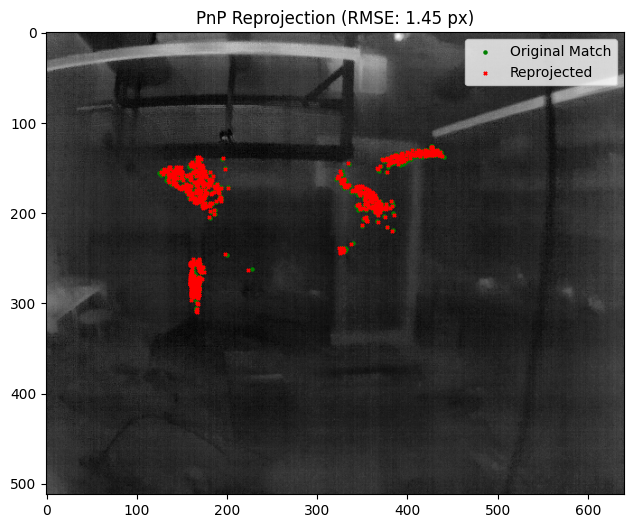

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_ir_pose_pnp(mkpts_rgb, mkpts_ir, depth_map, K_rgb, K_ir, dist_ir=None):
    """
    Estimate pose of IR camera relative to RGB camera using PnP.
    Points are transformed from RGB frame to IR frame: P_ir = R * P_rgb + t
    """
    # 1. Get 3D points in RGB frame
    points_3d = []
    points_2d_ir = []
    
    h, w = depth_map.shape
    
    # Filter valid points
    for i in range(len(mkpts_rgb)):
        u, v = mkpts_rgb[i]
        u_int, v_int = int(round(u)), int(round(v))
        
        # Check bounds
        if 0 <= u_int < w and 0 <= v_int < h:
            d = depth_map[v_int, u_int]
            
            # Ignore invalid depth (adjust thresholds as needed)
            if d > 0.1 and d < 100.0: 
                # Back-project: P = K_inv * [u, v, 1] * zThe Fix: You need to shrink the depth map values significantly. Try setting MANUAL_SCALE to 0.03 (approx 1/30th).


                z = d
                x = (u - K_rgb[0, 2]) * z / K_rgb[0, 0]
                y = (v - K_rgb[1, 2]) * z / K_rgb[1, 1]
                
                points_3d.append([x, y, z])
                points_2d_ir.append(mkpts_ir[i])
                
    points_3d = np.array(points_3d, dtype=np.float32)
    points_2d_ir = np.array(points_2d_ir, dtype=np.float32)
    
    print(f"PnP: Using {len(points_3d)} / {len(mkpts_rgb)} points")
    
    if len(points_3d) < 6: # Need at least 4, but 6 is safer for RANSAC
        print("Not enough valid points for PnP")
        return None, None, None, None, None, None
        
    # 2. Solve PnP with RANSAC
    # solvePnPRansac returns the rotation vector (rvec) and translation vector (tvec)
    # that transforms a 3D point expressed in the object coordinate frame (RGB)
    # to the camera coordinate frame (IR).
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        points_3d, 
        points_2d_ir, 
        K_ir, 
        dist_ir,
        reprojectionError=3.0, # Pixel error threshold
        iterationsCount=2000,
        confidence=0.999
    )
    
    if not success:
        print("PnP RANSAC failed")
        return None, None, None, None, None, None

    print(f"PnP Success! Inliers: {len(inliers)} / {len(points_3d)}")
    return success, rvec, tvec, inliers, points_3d, points_2d_ir

# 1. Resize depth map to match the original RGB image resolution
# We assume 'img_rgb' (or whatever variable holds your original RGB image) is available.
# If not, use the shape from the image loading cell.
target_h, target_w = img_rgb.shape[:2] 
print(f"Resizing depth map from {depth0_metric.shape} to ({target_h}, {target_w})")

depth0_metric_resized = cv2.resize(depth0_metric, (target_w, target_h), interpolation=cv2.INTER_NEAREST)


# 2. Run PnP with the RESIZED depth map
if 'mkpts_rgb' in locals():
    success, rvec, tvec, inliers, p3d, p2d = estimate_ir_pose_pnp(
        mkpts_rgb, 
        mkpts_ir, 
        depth0_metric_resized, # <--- Use resized depth map
        K_rgb0, 
        K_ir0, 
        d_ir0
    )

    if success:
        print("\nEstimated Translation (tvec):")
        print(tvec.flatten())
        print(f"Norm: {np.linalg.norm(tvec):.4f} meters")
        
        print("\nEstimated Rotation (rvec):")
        print(rvec.flatten())
        
        # Verification: Reproject points
        projected_points, _ = cv2.projectPoints(p3d[inliers.flatten()], rvec, tvec, K_ir0, d_ir0)
        projected_points = projected_points.squeeze()
        actual_points = p2d[inliers.flatten()]
        
        errors = np.linalg.norm(projected_points - actual_points, axis=1)
        rmse = np.sqrt(np.mean(errors**2))
        print(f"\nReprojection RMSE on inliers: {rmse:.4f} pixels")
        
        # Visualization
        plt.figure(figsize=(10, 6))
        if 'img_ir' in locals():
            plt.imshow(img_ir, cmap='gray')
        plt.scatter(actual_points[:, 0], actual_points[:, 1], c='g', s=5, label='Original Match')
        plt.scatter(projected_points[:, 0], projected_points[:, 1], c='r', s=5, marker='x', label='Reprojected')
        plt.legend()
        plt.title(f"PnP Reprojection (RMSE: {rmse:.2f} px)")
        plt.show()

In [ ]:
import cv2
img = cv2.imread("imgs/rgb0.png")

# Try with Set 0 params
h, w = img.shape[:2]
new_camera_matrix0, roi0 = cv2.getOptimalNewCameraMatrix(K_rgb0, d_rgb0, (w,h), 1, (w,h))
dst0 = cv2.undistort(img, K_rgb0, d_rgb0, None, new_camera_matrix0)

# Try with Set 1 params
new_camera_matrix1, roi1 = cv2.getOptimalNewCameraMatrix(K_rgb1, d_rgb1, (w,h), 1, (w,h))
dst1 = cv2.undistort(img, K_rgb1, d_rgb1, None, new_camera_matrix1)

# cv2.imshow("Undistorted with Params 0", dst0)
# cv2.imshow("Undistorted with Params 1", dst1)

: 